In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import gc

- Analyse effect of varying delay durations in 5 minute increments (5,10,15,20) to determine if adjustments to the transfer window are necessary. This is done by increasing the time gap by the delay duration
- We will treat our own classifier as the ground truth on how journeys should be grouped.
- For the transfer window, increment bus transfer window (includes bus-bus, bus-train, train-bus) by 5 minutes from 30mins to 60mins, while holding train-train transfers fixed at 15min
- Justification for holding train-train transfers fixed at 15min is that true transfer mostly only occur at certain stations (e.g. Newton) and there are a very low proportion of valid train-train transfers initially 
- Our goal is to test whether the transfer window that is specifically chose (e.g. 45min by LTA currently) is robust enough to handle delays
- We will calculate wrongly split and wrong merged rates. 
- Wrongly split: classifier says the pair is a transfer (same journey), but the window says the gap is too long and breaks them apart
- Wrongly merged: classifier says the pair is a new journey, but the window links them as a transfer 

In [2]:
RAIL_RAIL_WINDOW = 15
bus_windows = list(range(30, 65, 5))   # 30, 35, 40, 45, 50, 55, 60
delay_scenarios = [0, 5, 10, 15, 20]

Baseline spec

In [3]:
df3_with_regions = pd.read_pickle('../data/df3_with_regions.pkl')

In [4]:
df3_lenient_with_regions = pd.read_pickle('../data/df3_lenient_with_regions.pkl')

In [5]:
df3_strict_with_regions =  pd.read_pickle('../data/df3_strict_with_regions.pkl')

In [6]:
specs = {
    'baseline': df3_with_regions,
    'lenient':  df3_lenient_with_regions,
    'strict':   df3_strict_with_regions,
}

In [7]:
df3_with_regions.columns

Index(['BUS_SVC_NUM', 'CRD_NUM', 'DEST_LOC_ID_NUM', 'ENTRY_DT', 'ENTRY_TM',
       'EXIT_DT', 'EXIT_TM', 'JRNY_ID_NUM', 'ORIG_LOC_ID_NUM', 'RIDE_DISC_AMT',
       'RIDE_DIST_KM_CNT', 'RIDE_FARE_AMT', 'RIDE_ID_NUM', 'RIDE_MIN_CNT',
       'PATRON_CATG_ID_NUM', 'TRNSPT_MODE_CD', 'DEST_STATION_NAME',
       'DEST_MRK_ID_NUM', 'DEST_LATITUDE', 'DEST_LONGITUDE',
       'DEST_Travel_Type', 'ORIG_STATION_NAME', 'ORIG_MRK_ID_NUM',
       'ORIG_LATITUDE', 'ORIG_LONGITUDE', 'ORIG_Travel_Type', 'next_orig_lat',
       'next_orig_lon', 'next_orig_station', 'walk_distance',
       'PATRON_CATG_DESC_TXT', 'walking_speed_ms', 'service_day',
       'next_ENTRY_TM', 'next_ORIG_LOC_ID_NUM', 'next_BUS_SVC_NUM',
       'next_TRNSPT_MODE_CD', 'is_last_stage', 'missing_info',
       'same_bus_service', 'same_station_consecutive',
       'return_or_intermediate', 'binary_flag', 'binary_flag_reason',
       'binary_full_journey_seq', '(BINARY_Only)_journey_orig_station',
       '(BINARY_Only)_journey_entry_tm

Justification for not altering train-train window

In [32]:
print("Mode pair distribution in baseline df:")
print(df3_with_regions['mode_pair'].value_counts(dropna=False))

train_train = df3_with_regions[df3_with_regions['mode_pair'] == 'train_train'].copy()

print(f"\nTrain-train pairs: {len(train_train):,}")
print(f"Train-train as % of all rows: {(len(train_train) / len(df3_with_regions)) * 100:.2f}%")

print("\nTrain-train time gap summary:")
print(train_train['time_gap_mins'].describe())

print(f"\nWithin 15 mins: {(train_train['time_gap_mins'] <= 15).sum():,}")
print(f"Exceeds 15 mins: {(train_train['time_gap_mins'] > 15).sum():,}")
print(f"Same station consecutive: {train_train['same_station_consecutive'].sum():,}")
train_train_not_same = train_train[~train_train['same_station_consecutive']].copy()

print(f"Train-train NOT same station consecutive (potential valid transfer): {len(train_train_not_same):,}")

Mode pair distribution in baseline df:
mode_pair
other          2453068
bus_bus        1829510
train_train    1230987
bus_train       978125
train_bus       976922
Name: count, dtype: int64

Train-train pairs: 1,230,987
Train-train as % of all rows: 16.48%

Train-train time gap summary:
count    1.227762e+06
mean     3.104234e+02
std      2.520256e+02
min     -1.096667e+02
25%      7.565000e+01
50%      2.322500e+02
75%      5.633500e+02
max      1.074317e+03
Name: time_gap_mins, dtype: float64

Within 15 mins: 116,088
Exceeds 15 mins: 1,111,674
Same station consecutive: 987,581
Train-train NOT same station consecutive (potential valid transfer): 243,406


In [33]:
# 1. Exclude "others" from denominator (others is all last stage)
df_no_others = df3_with_regions[
    df3_with_regions['mode_pair'] != 'others'
].copy()

train_train = df_no_others[
    df_no_others['mode_pair'] == 'train_train'
].copy()


train_train_not_same = train_train[
    train_train['same_station_consecutive'] == False
].copy()

pct = len(train_train_not_same) / len(df_no_others) * 100

print(f"Train-train NOT same station consecutive: {len(train_train_not_same):,}")
print(f"Total transfers (excluding 'others'): {len(df_no_others):,}")
print(f"% of all (excluding 'others'): {pct:.2f}%")

Train-train NOT same station consecutive: 243,406
Total transfers (excluding 'others'): 7,468,612
% of all (excluding 'others'): 3.26%


In [9]:
def build_df_pairs(df):
    crds_with_missing = df[
        (df['is_last_stage'] == False) &
        (df['time_gap_mins'].isna())
    ]['CRD_NUM'].unique()

    df_pairs = df[
        (df['is_last_stage'] == False) &
        (~df['CRD_NUM'].isin(crds_with_missing)) &
        (df['PATRON_CATG_DESC_TXT'].notna())
    ].copy()

    print(f"  Cards removed (missing gap): {len(crds_with_missing):,}")
    print(f"  Ride pairs remaining:        {len(df_pairs):,}")
    return df_pairs

In [10]:
classifier_journeys_map             = {}  # spec → int
classifier_journeys_patron_map      = {}  # spec → {patron → int}

for spec_name, df_raw in specs.items():
    # overall
    classifier_journeys_map[spec_name] = int(
        df_raw.groupby('CRD_NUM')['BTS_journey_seq']
              .max().add(1).sum()
    )

    # by patron — journeys per card per patron, then sum
    classifier_journeys_patron_map[spec_name] = (
        df_raw.groupby(['PATRON_CATG_DESC_TXT', 'CRD_NUM'])['BTS_journey_seq']
              .max().add(1)
              .reset_index()
              .groupby('PATRON_CATG_DESC_TXT')['BTS_journey_seq']
              .sum()
              .to_dict()
    )

    print(f"Spec: {spec_name} | Classifier journeys: {classifier_journeys_map[spec_name]:,}")


Spec: baseline | Classifier journeys: 5,567,649
Spec: lenient | Classifier journeys: 5,511,408
Spec: strict | Classifier journeys: 5,649,792


In [11]:
def aggregate(df, group_col=None):
    rows = []
    groups = [None] if group_col is None else df[group_col].dropna().unique()

    for grp_val in groups:
        sub = df if grp_val is None else df[df[group_col] == grp_val]
        if len(sub) == 0:
            continue

        total_true = sub['ground_truth_transfer'].sum()
        total_non  = (~sub['ground_truth_transfer']).sum()
        n_cards    = sub['CRD_NUM'].nunique()

        for delay in delay_scenarios:
            for bus_window in bus_windows:
                ws = sub[f'wrongly_split_{delay}_{bus_window}'].sum()
                wm = sub[f'wrongly_merged_{delay}_{bus_window}'].sum()

                # window journeys — valid for all groups
                wt              = sub[f'window_transfer_{delay}_{bus_window}']
                window_breaks   = (~wt).sum()
                window_journeys = int(window_breaks + n_cards)

                row = {
                    'n_pairs':                    len(sub),
                    'n_cards':                    n_cards,
                    'ground_truth_transfer_n':    int(total_true),
                    'ground_truth_new_journey_n': int(total_non),
                    'delay_mins':                 delay,
                    'bus_window_mins':            bus_window,
                    'window_journeys':            window_journeys,
                    'wrongly_split_n':            int(ws),
                    'wrongly_merged_n':           int(wm),
                    'wrongly_split_pct':          ws / total_true * 100 if total_true > 0 else np.nan,
                    'wrongly_merged_pct':         wm / total_non  * 100 if total_non  > 0 else np.nan,
                    'wrongly_split_pct_all':      ws / len(sub) * 100,
                    'wrongly_merged_pct_all':     wm / len(sub) * 100,
                }
                if group_col is not None:
                    row[group_col] = grp_val
                rows.append(row)

    return pd.DataFrame(rows)

In [12]:
def aggregate_cross(df, group_col_1, group_col_2):
    rows = []

    # Create temporary columns that fill missing values with 'unknown'
    df_temp = df.copy()
    df_temp[f'{group_col_1}_fill'] = df_temp[group_col_1].fillna('unknown')
    df_temp[f'{group_col_2}_fill'] = df_temp[group_col_2].fillna('unknown')

    # Get all unique combinations (including 'unknown')
    groups = (
        df_temp[[f'{group_col_1}_fill', f'{group_col_2}_fill']]
        .drop_duplicates()
        .values
    )

    for grp_val_1, grp_val_2 in groups:
        sub = df_temp[
            (df_temp[f'{group_col_1}_fill'] == grp_val_1) &
            (df_temp[f'{group_col_2}_fill'] == grp_val_2)
        ]

        total_true = sub['ground_truth_transfer'].sum()
        total_non  = (~sub['ground_truth_transfer']).sum()
        n_cards    = sub['CRD_NUM'].nunique()

        for delay in delay_scenarios:
            for bus_window in bus_windows:
                ws = sub[f'wrongly_split_{delay}_{bus_window}'].sum()
                wm = sub[f'wrongly_merged_{delay}_{bus_window}'].sum()
                wt = sub[f'window_transfer_{delay}_{bus_window}']
                window_breaks = (~wt).sum()
                window_journeys = int(window_breaks + n_cards)

                # replace unknown if NaN
                val_1 = grp_val_1 if grp_val_1 != 'unknown' else np.nan
                val_2 = grp_val_2 if grp_val_2 != 'unknown' else np.nan

                rows.append({
                    group_col_1:                     val_1,
                    group_col_2:                     val_2,
                    'n_pairs':                       len(sub),
                    'n_cards':                       n_cards,
                    'ground_truth_transfer_n':       int(total_true),
                    'ground_truth_new_journey_n':    int(total_non),
                    'delay_mins':                    delay,
                    'bus_window_mins':               bus_window,
                    'window_journeys':               window_journeys,
                    'wrongly_split_n':               int(ws),
                    'wrongly_merged_n':              int(wm),
                    'wrongly_split_pct':             ws / total_true * 100 if total_true > 0 else np.nan,
                    'wrongly_merged_pct':            wm / total_non  * 100 if total_non  > 0 else np.nan,
                    'wrongly_split_pct_all':         ws / len(sub) * 100,
                    'wrongly_merged_pct_all':        wm / len(sub) * 100,
                })

    return pd.DataFrame(rows)

In [ ]:
all_overall     = []
all_patron      = []
all_dest_region = []
all_orig_region = []
all_hour        = []
all_hour_dest_region = []

for spec_name, df_raw in specs.items():
    print(f"\n{'='*50}")
    print(f"Spec: {spec_name}")
    print(f"{'='*50}")

    df_pairs = build_df_pairs(df_raw)
    df_pairs['ground_truth_transfer'] = df_pairs['is_same_journey_final']
    df_pairs['next_entry_hour']       = df_pairs['next_ENTRY_TM'].dt.hour

    total_true = df_pairs['ground_truth_transfer'].sum()
    total_non  = (~df_pairs['ground_truth_transfer']).sum()
    print(f"  True transfers:    {total_true:,}")
    print(f"  True new journeys: {total_non:,}")

    # precompute all delay + window combi
    new_cols = {}
    for delay in delay_scenarios:
        delayed_gap = df_pairs['time_gap_mins'] + delay
        new_cols[f'delayed_gap_{delay}'] = delayed_gap

        for bus_window in bus_windows:
            effective_window = np.where(
                df_pairs['mode_pair'] == 'train_train',
                RAIL_RAIL_WINDOW,
                bus_window
            )
            same_station_train_only = (
                (df_pairs['TRNSPT_MODE_CD'] == 2) &
                (df_pairs['next_TRNSPT_MODE_CD'] == 2) &
                df_pairs['same_station_consecutive']
            )
            # window rules: no same bus, no same train station
            window_transfer = (
                ~df_pairs['same_bus_service'] &
                ~same_station_train_only &
                (delayed_gap <= effective_window)
            )
            wrongly_split  = df_pairs['ground_truth_transfer'] & ~window_transfer
            wrongly_merged = ~df_pairs['ground_truth_transfer'] & window_transfer

            new_cols[f'window_transfer_{delay}_{bus_window}'] = window_transfer
            new_cols[f'wrongly_split_{delay}_{bus_window}']   = wrongly_split
            new_cols[f'wrongly_merged_{delay}_{bus_window}']  = wrongly_merged

            print(
                f"  delay={delay:>2}min | window={bus_window}min | "
                f"wrongly_split={wrongly_split.sum():,} ({wrongly_split.sum()/total_true*100:.2f}%) | "
                f"wrongly_merged={wrongly_merged.sum():,} ({wrongly_merged.sum()/total_non*100:.2f}%)"
            )

    df_pairs = pd.concat(
        [df_pairs, pd.DataFrame(new_cols, index=df_pairs.index)],
        axis=1
    )
    print(f"\n  Precomputed columns: {len(new_cols)}")

    overall_tmp     = aggregate(df_pairs, group_col=None)
    patron_tmp      = aggregate(df_pairs, group_col='PATRON_CATG_DESC_TXT')
    dest_region_tmp = aggregate(df_pairs, group_col='dest_region')
    orig_region_tmp = aggregate(df_pairs, group_col='orig_region')
    hour_tmp        = aggregate(df_pairs, group_col='next_entry_hour')
    hour_dest_region_tmp = aggregate_cross(df_pairs, 'next_entry_hour', 'dest_region')

    for tmp in [overall_tmp, patron_tmp, dest_region_tmp, orig_region_tmp, hour_tmp]:
        tmp['spec'] = spec_name
    hour_dest_region_tmp['spec'] = spec_name

    all_overall.append(overall_tmp)
    all_patron.append(patron_tmp)
    all_dest_region.append(dest_region_tmp)
    all_orig_region.append(orig_region_tmp)
    all_hour.append(hour_tmp)
    all_hour_dest_region.append(hour_dest_region_tmp)

    print(f"  Done: {spec_name}")


Spec: baseline
  Cards removed (missing gap): 28,144
  Ride pairs remaining:        4,753,028
  True transfers:    1,874,130
  True new journeys: 2,878,898
  delay= 0min | window=30min | wrongly_split=363 (0.02%) | wrongly_merged=246,937 (8.58%)
  delay= 0min | window=35min | wrongly_split=175 (0.01%) | wrongly_merged=287,535 (9.99%)
  delay= 0min | window=40min | wrongly_split=165 (0.01%) | wrongly_merged=322,564 (11.20%)
  delay= 0min | window=45min | wrongly_split=165 (0.01%) | wrongly_merged=352,484 (12.24%)
  delay= 0min | window=50min | wrongly_split=165 (0.01%) | wrongly_merged=378,658 (13.15%)
  delay= 0min | window=55min | wrongly_split=165 (0.01%) | wrongly_merged=402,675 (13.99%)
  delay= 0min | window=60min | wrongly_split=165 (0.01%) | wrongly_merged=424,583 (14.75%)
  delay= 5min | window=30min | wrongly_split=1,799 (0.10%) | wrongly_merged=197,052 (6.84%)
  delay= 5min | window=35min | wrongly_split=817 (0.04%) | wrongly_merged=244,954 (8.51%)
  delay= 5min | window=40m

In [14]:
overall_df     = pd.concat(all_overall,     ignore_index=True)
patron_df      = pd.concat(all_patron,      ignore_index=True)
dest_region_df = pd.concat(all_dest_region, ignore_index=True)
orig_region_df = pd.concat(all_orig_region, ignore_index=True)
hour_df        = pd.concat(all_hour,        ignore_index=True)
hour_dest_region_df = pd.concat(all_hour_dest_region, ignore_index=True)

# tag breakdown types
overall_df['breakdown_type']     = 'overall'
overall_df['breakdown_value']    = 'overall'

patron_df['breakdown_type']      = 'patron'
patron_df = patron_df.rename(columns={'PATRON_CATG_DESC_TXT': 'breakdown_value'})

dest_region_df['breakdown_type'] = 'dest_region'
dest_region_df = dest_region_df.rename(columns={'dest_region': 'breakdown_value'})

orig_region_df['breakdown_type'] = 'orig_region'
orig_region_df = orig_region_df.rename(columns={'orig_region': 'breakdown_value'})

hour_df['breakdown_type']        = 'next_entry_hour'
hour_df = hour_df.rename(columns={'next_entry_hour': 'breakdown_value'})

hour_dest_region_df['breakdown_type'] = 'hour_x_dest_region'
hour_dest_region_df = hour_dest_region_df.rename(
    columns={'next_entry_hour': 'breakdown_value'}
)

# classifier journeys
overall_df['classifier_journeys'] = overall_df['spec'].map(classifier_journeys_map)

def _lookup(row, mapping):
    return mapping.get(row['spec'], {}).get(row['breakdown_value'], np.nan)

patron_df['classifier_journeys'] = patron_df.apply(lambda r: _lookup(r, classifier_journeys_patron_map), axis=1)

# hour and regions: window_journeys and classifier_journeys not meaningful
# a journey spans multiple hours and regions so counting by hour and region double counts. 
dest_region_df['classifier_journeys'] = np.nan
orig_region_df['classifier_journeys'] = np.nan
hour_df['classifier_journeys'] = np.nan
hour_df['window_journeys']     = np.nan
hour_dest_region_df['classifier_journeys'] = np.nan 
dest_region_df['window_journeys'] = np.nan
orig_region_df['window_journeys'] = np.nan

In [31]:
final_df = pd.concat(
    # FIXED: hour_df was duplicated (hour_df, hour_df) — removed duplicate
    [overall_df, patron_df, dest_region_df, orig_region_df, hour_df, hour_dest_region_df],
    ignore_index=True
)

col_order = [
    'spec', 'breakdown_type', 'breakdown_value', 'dest_region',
    'delay_mins', 'bus_window_mins',
    'n_pairs', 'n_cards',
    'classifier_journeys', 'window_journeys',
    'ground_truth_transfer_n', 'ground_truth_new_journey_n',
    'wrongly_split_n',   'wrongly_merged_n',
    'wrongly_split_pct', 'wrongly_merged_pct',
    'wrongly_split_pct_all', 'wrongly_merged_pct_all',
]
final_df = final_df[col_order]

print(f"\nFinal shape: {final_df.shape}")
print(final_df['breakdown_type'].value_counts())

final_df.to_csv('../data/final_delays.csv', index=False)
print("Saved: final_delays.csv")


Final shape: (114240, 18)
breakdown_type
hour_x_dest_region    101115
dest_region             5355
orig_region             5355
next_entry_hour         1995
patron                   315
overall                  105
Name: count, dtype: int64
Saved: final_delays.csv


comparison: can delete after verified

In [16]:
# Filter overall and hour_region rows
df = final_df
overall = df[df['breakdown_type'] == 'overall'].copy()
hour_region = df[df['breakdown_type'] == 'hour_x_dest_region'].copy()

# Create a key for grouping
overall['key'] = overall['spec'] + '_' + overall['delay_mins'].astype(str) + '_' + overall['bus_window_mins'].astype(str)
hour_region['key'] = hour_region['spec'] + '_' + hour_region['delay_mins'].astype(str) + '_' + hour_region['bus_window_mins'].astype(str)

# Sum hour_region values by key
hr_agg = hour_region.groupby('key').agg({
    'n_pairs': 'sum',
    'wrongly_split_n': 'sum',
    'wrongly_merged_n': 'sum',
    'ground_truth_transfer_n': 'sum',
    'ground_truth_new_journey_n': 'sum'
}).reset_index()

# Merge with overall
comparison = overall[['key', 'n_pairs', 'wrongly_split_n', 'wrongly_merged_n', 
                      'ground_truth_transfer_n', 'ground_truth_new_journey_n']].merge(
    hr_agg, on='key', suffixes=('_overall', '_hr')
)

# Check for differences
comparison['n_pairs_diff'] = comparison['n_pairs_overall'] - comparison['n_pairs_hr']
comparison['split_diff'] = comparison['wrongly_split_n_overall'] - comparison['wrongly_split_n_hr']
comparison['merged_diff'] = comparison['wrongly_merged_n_overall'] - comparison['wrongly_merged_n_hr']

# Show mismatches (non-zero differences)
mismatches = comparison[(comparison['n_pairs_diff'] != 0) | 
                        (comparison['split_diff'] != 0) | 
                        (comparison['merged_diff'] != 0)]

if len(mismatches) == 0:
    print("All totals match. Hour_region sums equal overall for all (spec, delay, window).")
else:
    print("Mismatches found:")
    print(mismatches[['key', 'n_pairs_diff', 'split_diff', 'merged_diff']])

All totals match. Hour_region sums equal overall for all (spec, delay, window).


In [17]:
def query_delay_sim(
    delay_mins:      int,
    bus_window:      int,
    classifier_type: str,
    patron:          str = 'all',
    df:              pd.DataFrame = None
):
    if df is None:
        raise ValueError("Please provide final_df")

    valid_delays  = [0, 5, 10, 15, 20]
    valid_windows = list(range(35, 65, 5))
    valid_specs   = ['baseline', 'lenient', 'strict']

    if delay_mins      not in valid_delays:  raise ValueError(f"delay_mins must be one of {valid_delays}")
    if bus_window      not in valid_windows: raise ValueError(f"bus_window must be one of {valid_windows}")
    if classifier_type not in valid_specs:   raise ValueError(f"classifier_type must be one of {valid_specs}")

    sub = df[
        (df['delay_mins']      == delay_mins)  &
        (df['bus_window_mins'] == bus_window)  &
        (df['spec']            == classifier_type)
    ].copy()

    if sub.empty:
        raise ValueError("No data found for given parameters")

    if patron == 'all':
        main_row = sub[sub['breakdown_type'] == 'overall'].iloc[0]
    else:
        patron_rows = sub[sub['breakdown_type'] == 'patron']
        if patron not in patron_rows['breakdown_value'].values:
            raise ValueError(f"Patron '{patron}' not found. Available: {patron_rows['breakdown_value'].tolist()}")
        main_row = patron_rows[patron_rows['breakdown_value'] == patron].iloc[0]

    classifier_journeys = int(main_row['classifier_journeys']) if not pd.isna(main_row['classifier_journeys']) else None
    window_journeys     = int(main_row['window_journeys'])     if not pd.isna(main_row['window_journeys'])     else None
    journey_difference  = (window_journeys - classifier_journeys) if (window_journeys and classifier_journeys) else None

    def get_breakdown(breakdown_type, col_name):
        return (
            sub[sub['breakdown_type'] == breakdown_type][[
                'breakdown_value', 'n_pairs', 'n_cards',
                'classifier_journeys', 'window_journeys',
                'wrongly_split_n',       'wrongly_merged_n',
                'wrongly_split_pct',     'wrongly_merged_pct',
                'wrongly_split_pct_all', 'wrongly_merged_pct_all',
            ]]
            .rename(columns={'breakdown_value': col_name})
            .sort_values('wrongly_split_pct', ascending=False)
            .reset_index(drop=True)
        )


    def get_hour_region_breakdown(region=None):
        sub_cross = sub[sub['breakdown_type'] == 'hour_x_dest_region'].copy()
        if region is not None:
            sub_cross = sub_cross[sub_cross['dest_region'] == region]
        return (
            sub_cross[[
                'breakdown_value', 'dest_region', 'n_pairs',
                'wrongly_split_n',       'wrongly_merged_n',
                'wrongly_split_pct',     'wrongly_merged_pct',
            ]]
            .rename(columns={'breakdown_value': 'hour'})
            .sort_values(['dest_region', 'hour'])
            .reset_index(drop=True)
        )

    
    return {
        'spec':                classifier_type,
        'delay_mins':          delay_mins,
        'bus_window_mins':     bus_window,
        'patron':              patron,
        'classifier_journeys': classifier_journeys,
        'window_journeys':     window_journeys,
        'journey_difference':  journey_difference,
        'wrongly_split_n':     int(main_row['wrongly_split_n']),
        'wrongly_merged_n':    int(main_row['wrongly_merged_n']),
        'wrongly_split_pct':   float(main_row['wrongly_split_pct']),
        'wrongly_merged_pct':  float(main_row['wrongly_merged_pct']),
        'by_patron':           get_breakdown('patron',          'patron'),
        'by_dest_region':      get_breakdown('dest_region',     'dest_region'),
        'by_orig_region':      get_breakdown('orig_region',     'orig_region'),
        'by_hour':             get_breakdown('next_entry_hour', 'hour'),
        'by_hour_dest_region': get_hour_region_breakdown(region=None),
    }

Results
- by patron
- by dest_regions
1. Wrongly split percentage by window, across delays (Overall)
2. Wrongly merged % by window, across delays (Overall)
3. Trade-off curve comparing wrongly split with wrongly merged across windows and delays
4. Wrongly split % by patron at window=45 across delays (looking at LTA's current window)
5. 

In [18]:
spec_colors  = {'baseline': 'steelblue', 'lenient': 'seagreen', 'strict': 'tomato'}
delay_colors = {0: '#d3d3d3', 5: '#a8c8e8', 10: '#5a9fd4', 15: '#e88a5a', 20: '#c0392b'}

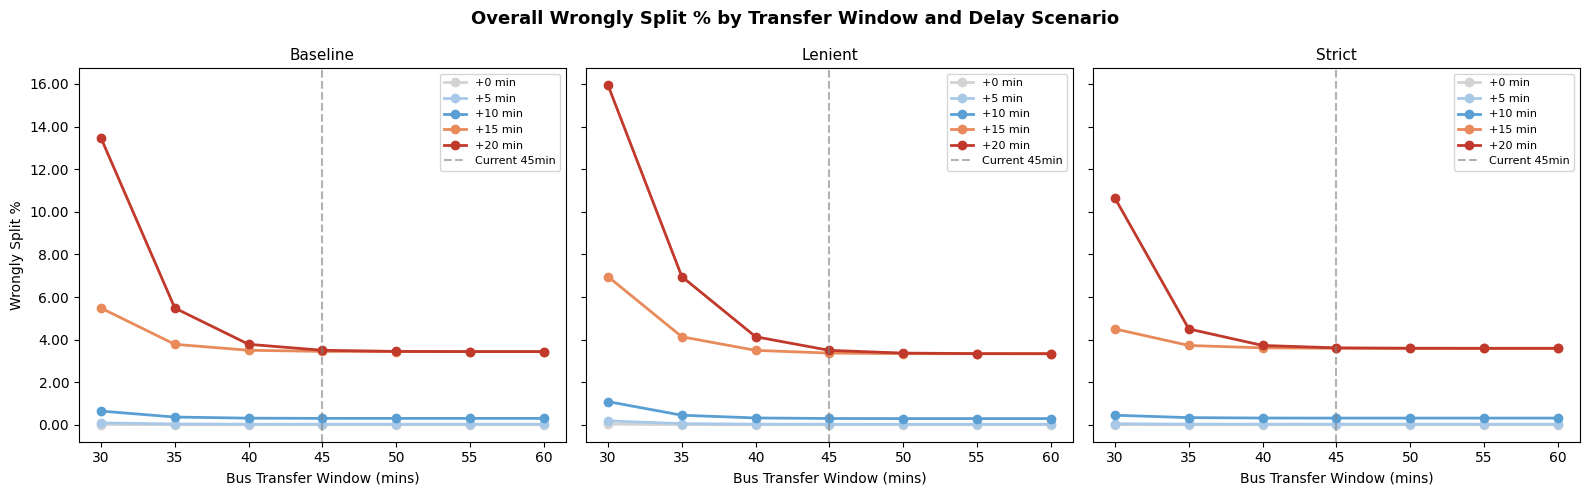

In [ ]:
#plot 1

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('Overall Wrongly Split % by Transfer Window and Delay Scenario', fontsize=13, fontweight='bold')

for i, spec in enumerate(specs):
    ax = axes[i]
    sub = final_df[
        (final_df['breakdown_type'] == 'overall') &
        (final_df['spec'] == spec)
    ]
    for delay in delay_scenarios:
        d = sub[sub['delay_mins'] == delay].sort_values('bus_window_mins')
        ax.plot(d['bus_window_mins'], d['wrongly_split_pct'],
                marker='o', label=f'+{delay} min', color=delay_colors[delay], linewidth=2)

    ax.axvline(45, color='gray', linestyle='--', alpha=0.6, label='Current 45min')
    ax.set_title(spec.capitalize(), fontsize=11)
    ax.set_xlabel('Bus Transfer Window (mins)')
    ax.set_ylabel('Wrongly Split %' if i == 0 else '')
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

plt.tight_layout()
#plt.savefig('plot1_overall_wrongly_split.png', dpi=150, bbox_inches='tight')
plt.show()

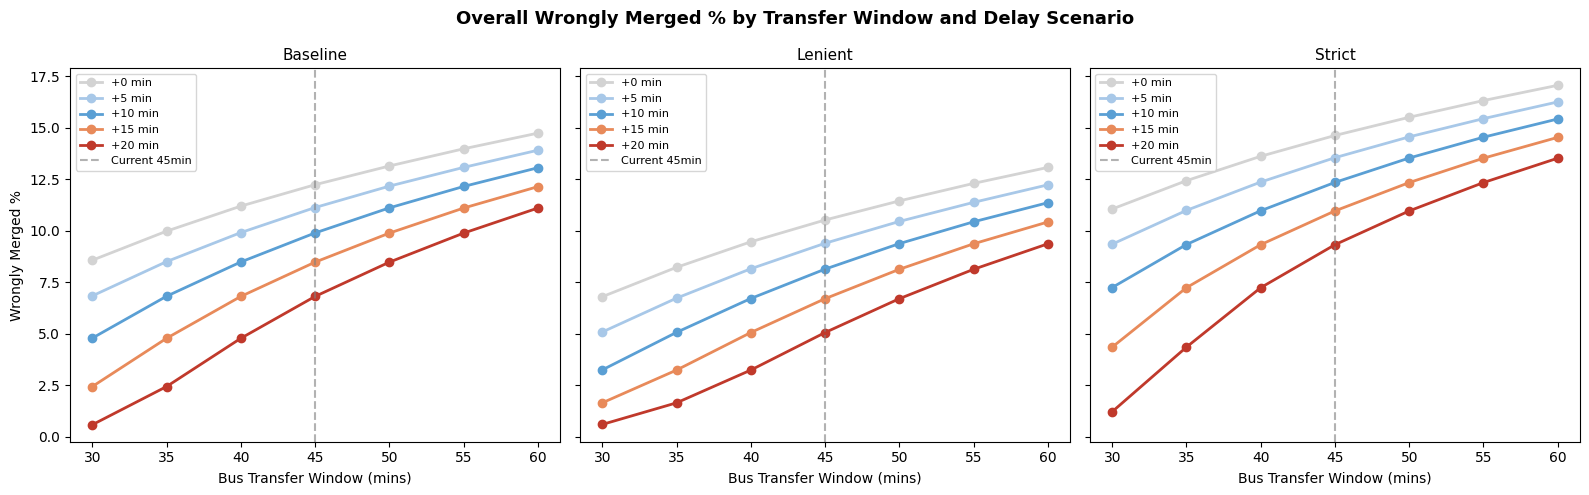

In [ ]:
#plot2
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('Overall Wrongly Merged % by Transfer Window and Delay Scenario', fontsize=13, fontweight='bold')

for i, spec in enumerate(specs):
    ax = axes[i]
    sub = final_df[
        (final_df['breakdown_type'] == 'overall') &
        (final_df['spec'] == spec)
    ]
    for delay in delay_scenarios:
        d = sub[sub['delay_mins'] == delay].sort_values('bus_window_mins')
        ax.plot(d['bus_window_mins'], d['wrongly_merged_pct'],
                marker='o', label=f'+{delay} min', color=delay_colors[delay], linewidth=2)

    ax.axvline(45, color='gray', linestyle='--', alpha=0.6, label='Current 45min')
    ax.set_title(spec.capitalize(), fontsize=11)
    ax.set_xlabel('Bus Transfer Window (mins)')
    ax.set_ylabel('Wrongly Merged %' if i == 0 else '')
    ax.legend(fontsize=8)

plt.tight_layout()
#plt.savefig('plot2_overall_wrongly_merged.png', dpi=150, bbox_inches='tight')
plt.show()

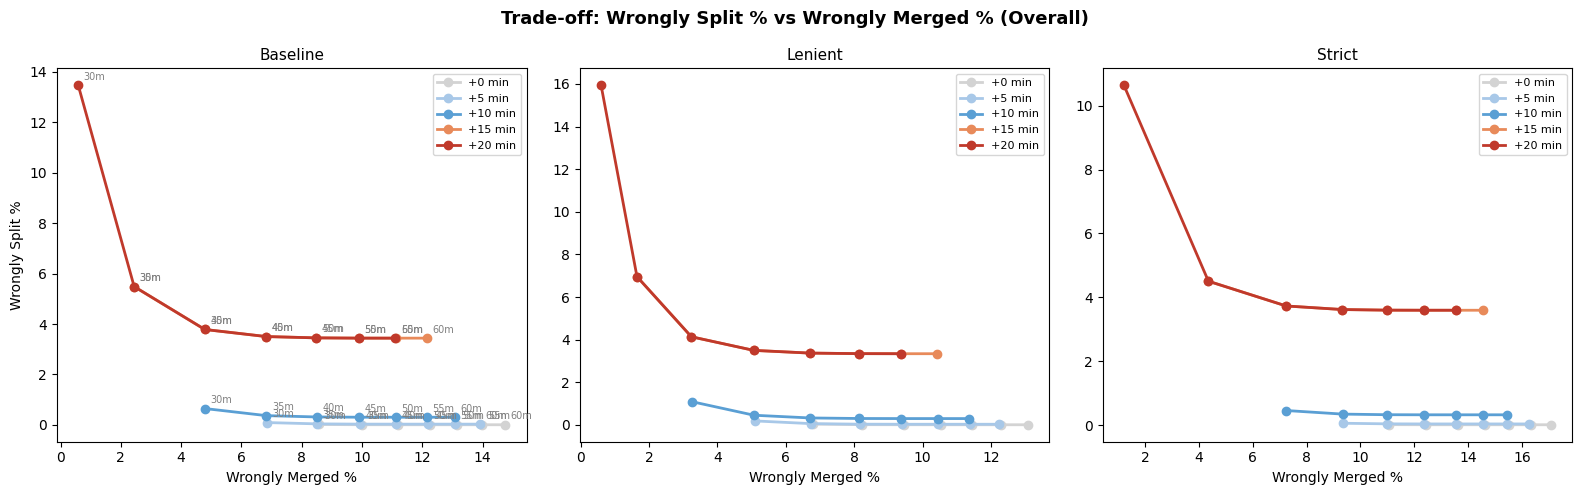

In [ ]:
#plot3
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Trade-off: Wrongly Split % vs Wrongly Merged % (Overall)', fontsize=13, fontweight='bold')

for i, spec in enumerate(specs):
    ax = axes[i]
    sub = final_df[
        (final_df['breakdown_type'] == 'overall') &
        (final_df['spec'] == spec)
    ]
    for delay in delay_scenarios:
        d = sub[sub['delay_mins'] == delay].sort_values('bus_window_mins')
        ax.plot(d['wrongly_merged_pct'], d['wrongly_split_pct'],
                marker='o', label=f'+{delay} min', color=delay_colors[delay], linewidth=2)
        # annotate window widths on baseline only to avoid clutter
        if spec == 'baseline':
            for _, row in d.iterrows():
                ax.annotate(f"{int(row['bus_window_mins'])}m",
                            xy=(row['wrongly_merged_pct'], row['wrongly_split_pct']),
                            xytext=(4, 4), textcoords='offset points', fontsize=7, color='gray')

    ax.set_title(spec.capitalize(), fontsize=11)
    ax.set_xlabel('Wrongly Merged %')
    ax.set_ylabel('Wrongly Split %' if i == 0 else '')
    ax.legend(fontsize=8)

plt.tight_layout()
#plt.savefig('plot3_tradeoff_curve.png', dpi=150, bbox_inches='tight')
plt.show()

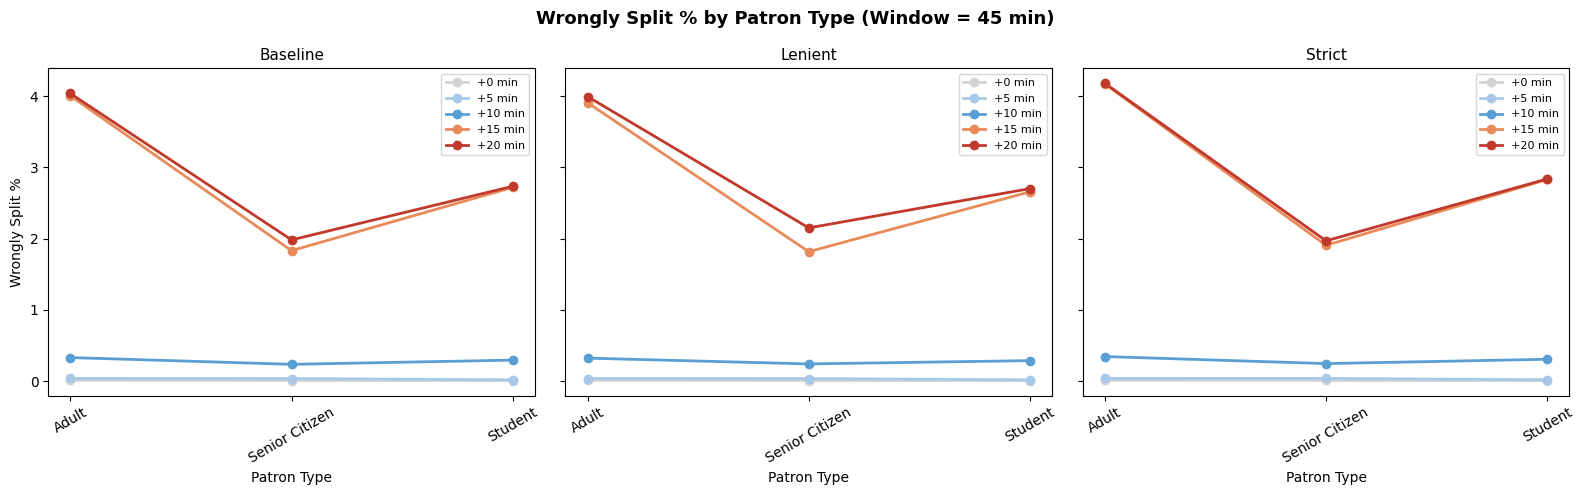

In [ ]:
#plot 4
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('Wrongly Split % by Patron Type (Window = 45 min)', fontsize=13, fontweight='bold')

for i, spec in enumerate(specs):
    ax = axes[i]
    sub = final_df[
        (final_df['breakdown_type'] == 'patron') &
        (final_df['spec'] == spec) &
        (final_df['bus_window_mins'] == 45)
    ]
    patrons = sub[sub['delay_mins'] == 0].sort_values('wrongly_split_pct', ascending=False)['breakdown_value'].tolist()

    for delay in delay_scenarios:
        d = sub[sub['delay_mins'] == delay].set_index('breakdown_value').reindex(patrons)
        ax.plot(patrons, d['wrongly_split_pct'],
                marker='o', label=f'+{delay} min', color=delay_colors[delay], linewidth=2)

    ax.set_title(spec.capitalize(), fontsize=11)
    ax.set_xlabel('Patron Type')
    ax.set_ylabel('Wrongly Split %' if i == 0 else '')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

plt.tight_layout()
#plt.savefig('plot4_patron_wrongly_split.png', dpi=150, bbox_inches='tight')
plt.show()


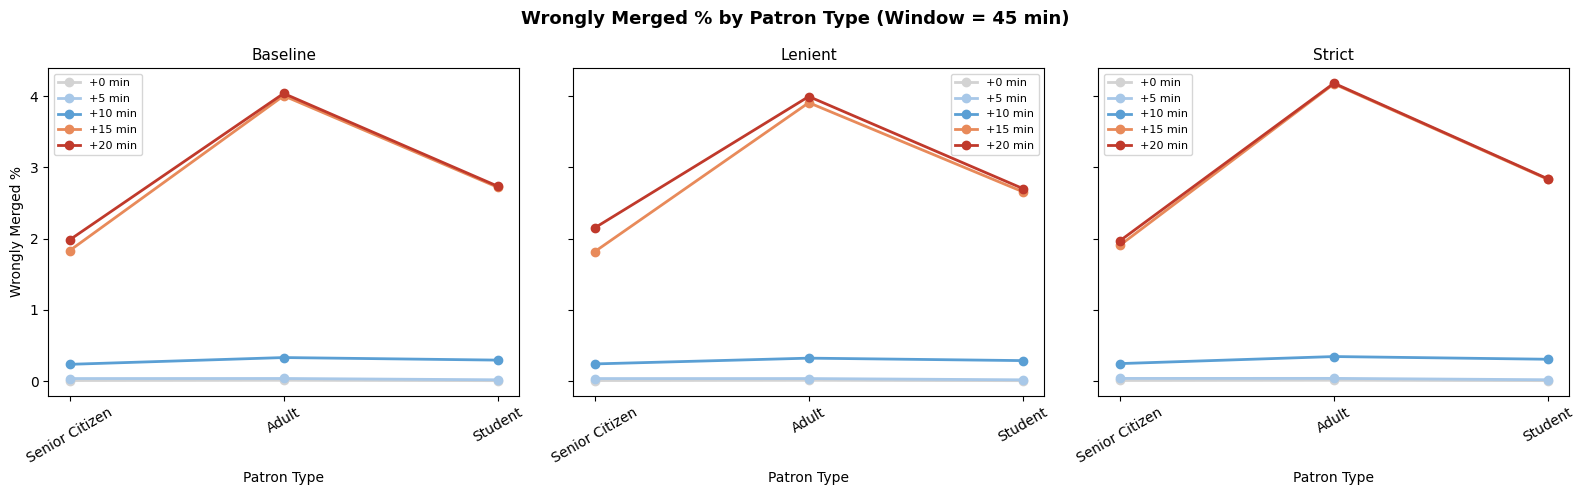

In [30]:
#plot 4.1
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('Wrongly Merged % by Patron Type (Window = 45 min)', fontsize=13, fontweight='bold')

for i, spec in enumerate(specs):
    ax = axes[i]
    sub = final_df[
        (final_df['breakdown_type'] == 'patron') &
        (final_df['spec'] == spec) &
        (final_df['bus_window_mins'] == 45)
    ]
    patrons = sub[sub['delay_mins'] == 0].sort_values('wrongly_merged_pct', ascending=False)['breakdown_value'].tolist()

    for delay in delay_scenarios:
        d = sub[sub['delay_mins'] == delay].set_index('breakdown_value').reindex(patrons)
        ax.plot(patrons, d['wrongly_split_pct'],
                marker='o', label=f'+{delay} min', color=delay_colors[delay], linewidth=2)

    ax.set_title(spec.capitalize(), fontsize=11)
    ax.set_xlabel('Patron Type')
    ax.set_ylabel('Wrongly Merged %' if i == 0 else '')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

plt.tight_layout()
#plt.savefig('plot4_patron_wrongly_split.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#plot 5
for spec in specs:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    fig.suptitle(f'Wrongly Split % by Patron × Window — {spec.capitalize()}', fontsize=12, fontweight='bold')

    for ax, delay in zip(axes, [0, 20]):
        sub = final_df[
            (final_df['breakdown_type'] == 'patron') &
            (final_df['spec'] == spec) &
            (final_df['delay_mins'] == delay)
        ]
        pivot = sub.pivot(index='breakdown_value', columns='bus_window_mins', values='wrongly_split_pct')
        sns.heatmap(pivot, ax=ax, cmap='YlOrRd', annot=True, fmt='.2f',
                    annot_kws={'size': 8}, cbar_kws={'label': 'Wrongly Split %'})
        ax.set_title(f'Delay = +{delay} min')
        ax.set_xlabel('Bus Window (mins)')
        ax.set_ylabel('Patron' if delay == 0 else '')

    plt.tight_layout()
   #plt.savefig(f'plot5_patron_heatmap_{spec}.png', dpi=150, bbox_inches='tight')
    plt.show()

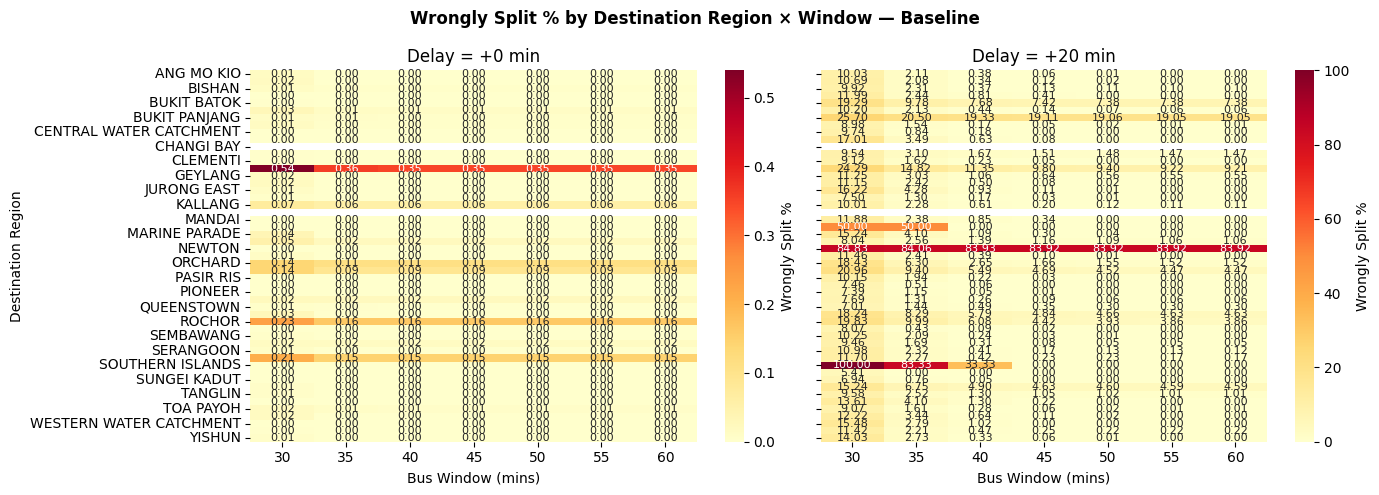

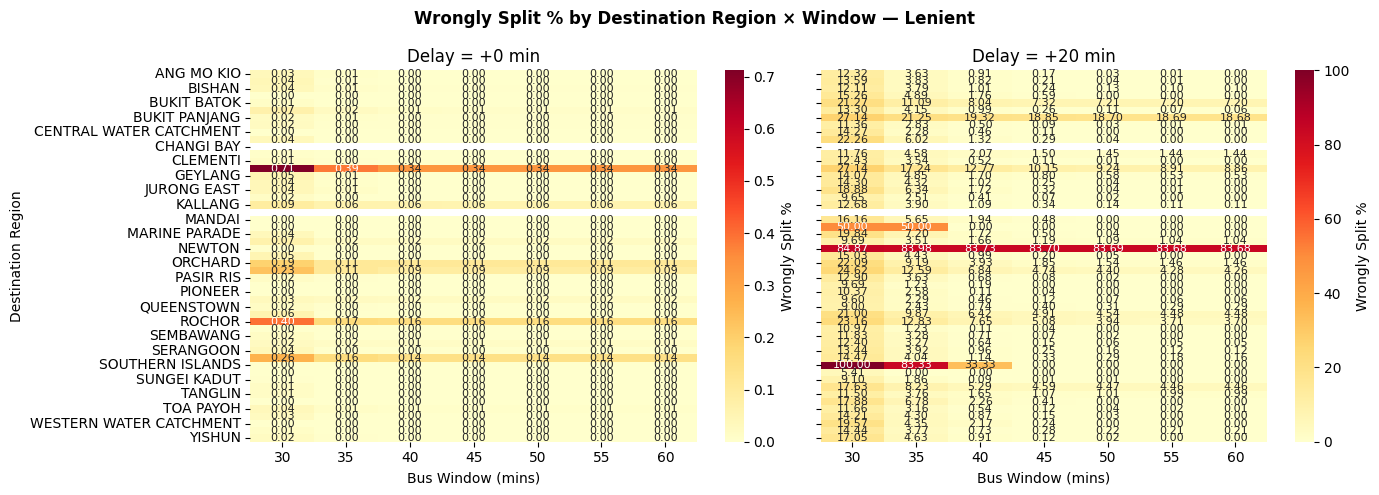

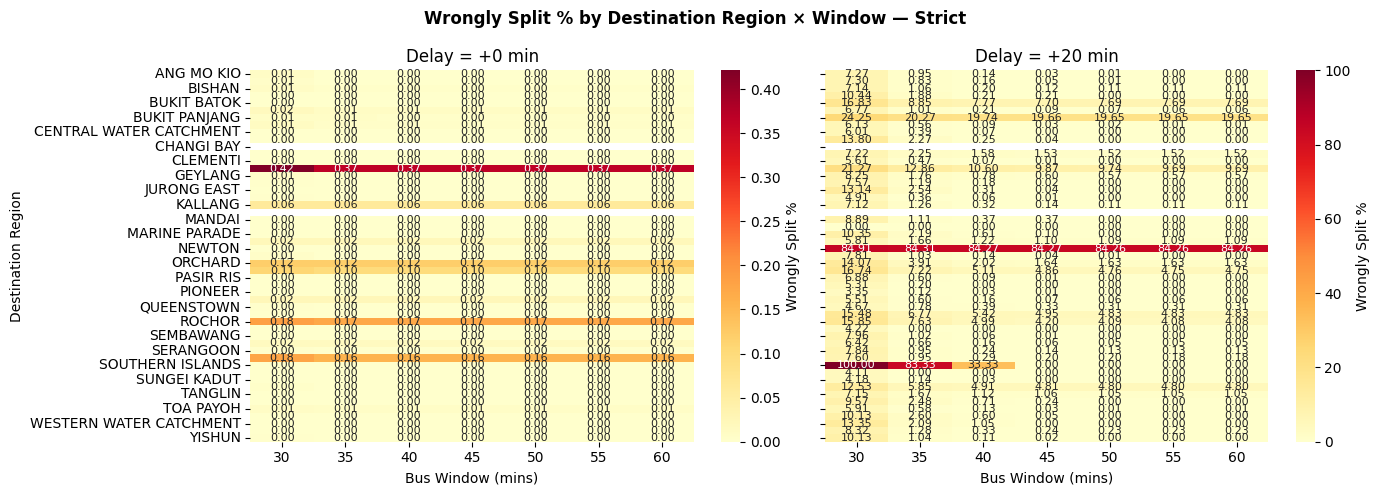

In [ ]:
#plot 7
for spec in specs:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig.suptitle(f'Wrongly Split % by Destination Region × Window — {spec.capitalize()}', fontsize=12, fontweight='bold')

    for ax, delay in zip(axes, [0, 20]):
        sub = final_df[
            (final_df['breakdown_type'] == 'dest_region') &
            (final_df['spec'] == spec) &
            (final_df['delay_mins'] == delay)
        ]
        pivot = sub.pivot(index='breakdown_value', columns='bus_window_mins', values='wrongly_split_pct')
        sns.heatmap(pivot, ax=ax, cmap='YlOrRd', annot=True, fmt='.2f',
                    annot_kws={'size': 8}, cbar_kws={'label': 'Wrongly Split %'})
        ax.set_title(f'Delay = +{delay} min')
        ax.set_xlabel('Bus Window (mins)')
        ax.set_ylabel('Destination Region' if delay == 0 else '')

    plt.tight_layout()
    #plt.savefig(f'plot7_dest_region_heatmap_{spec}.png', dpi=150, bbox_inches='tight')
    plt.show()

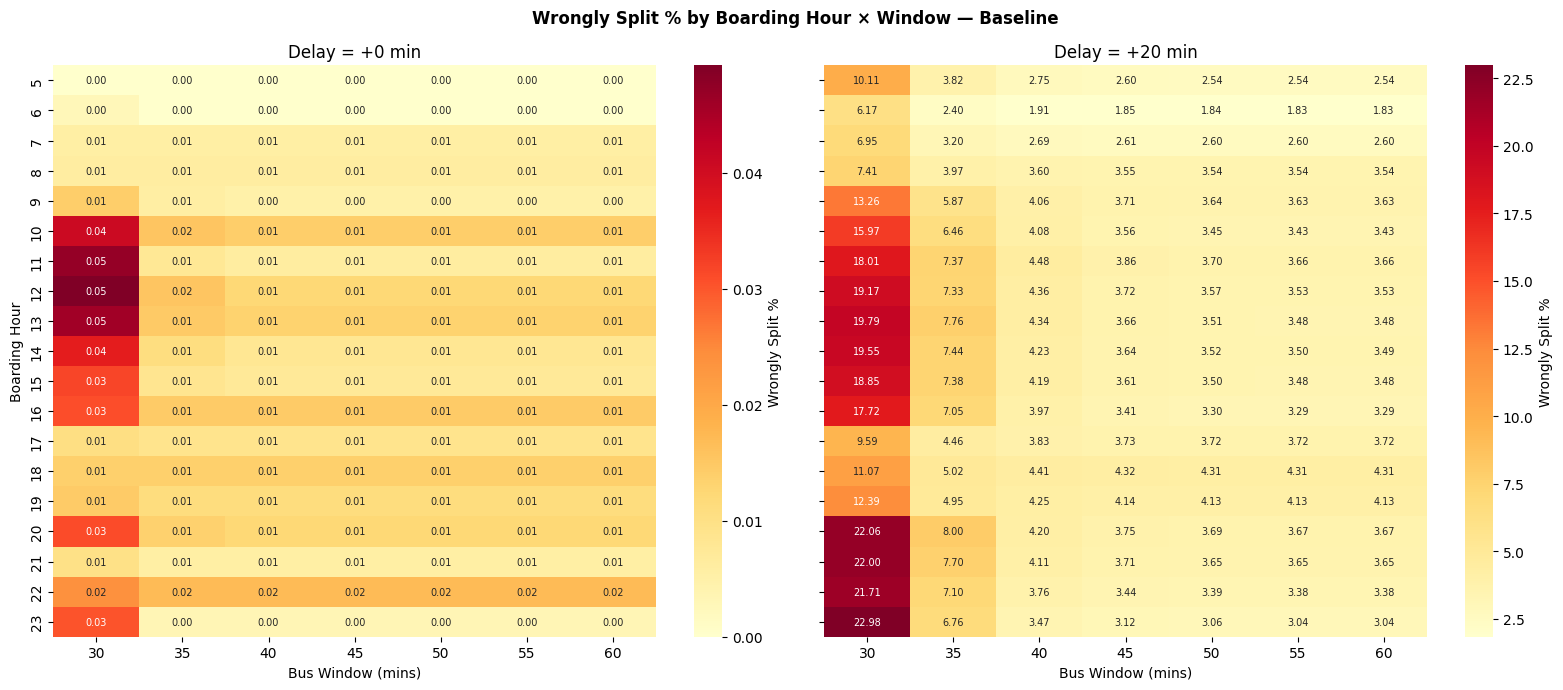

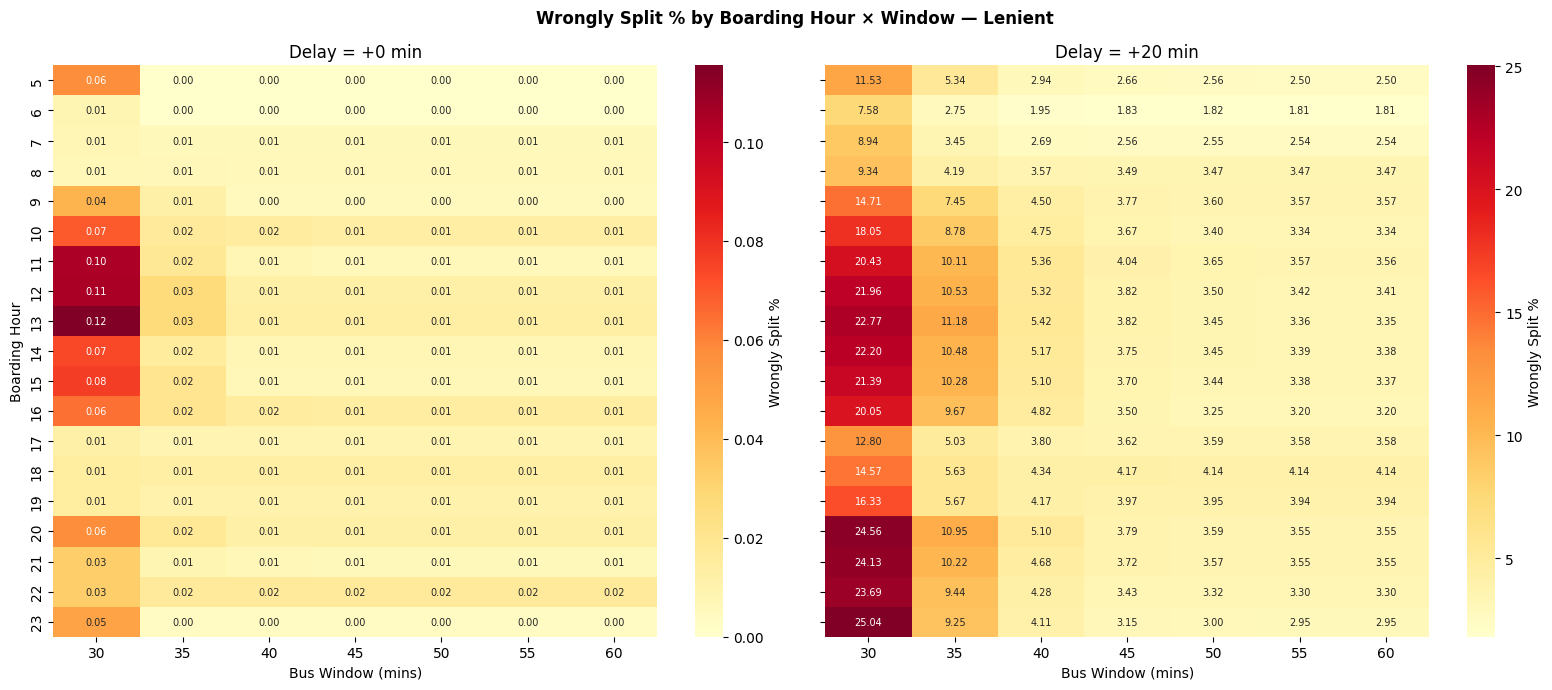

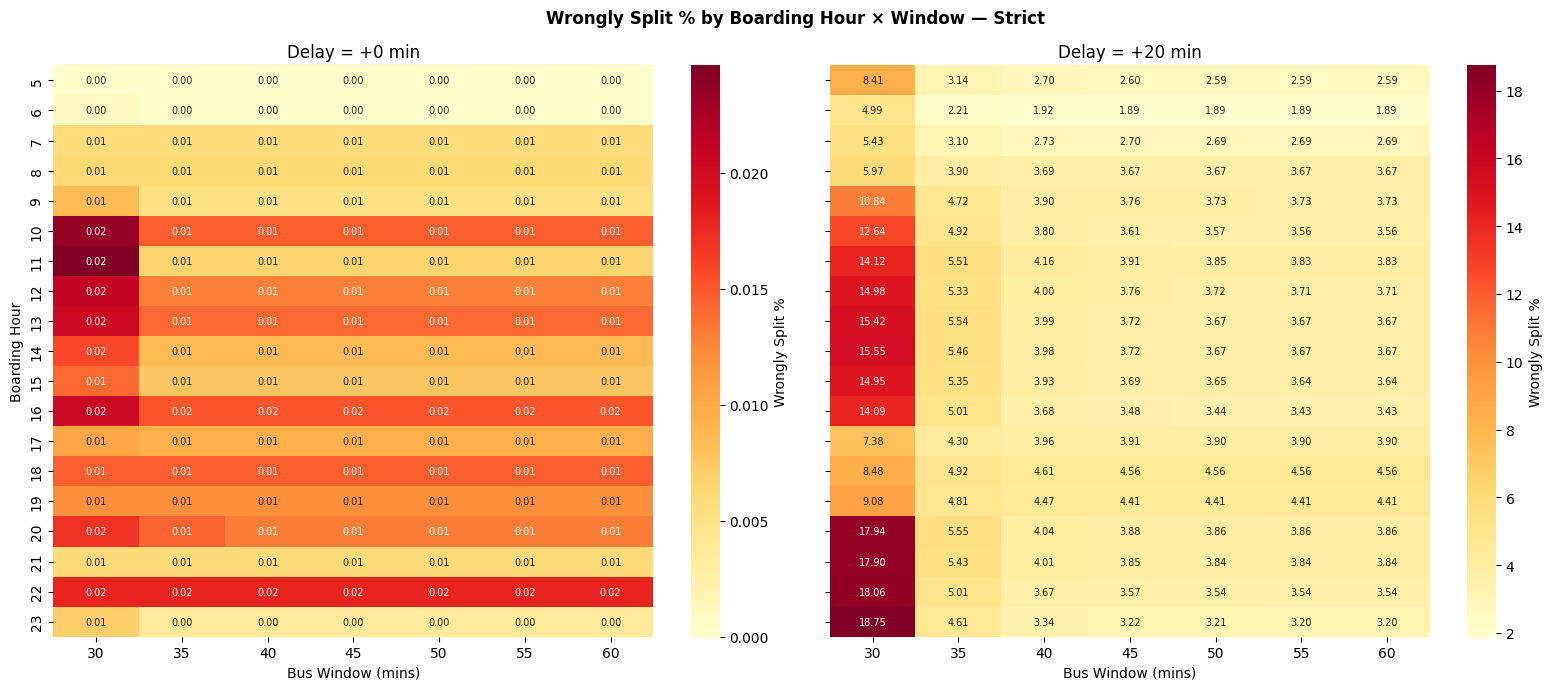

In [ ]:
#plot 8
for spec in specs:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
    fig.suptitle(f'Wrongly Split % by Boarding Hour × Window — {spec.capitalize()}', fontsize=12, fontweight='bold')

    for ax, delay in zip(axes, [0, 20]):
        sub = final_df[
            (final_df['breakdown_type'] == 'next_entry_hour') &
            (final_df['spec'] == spec) &
            (final_df['delay_mins'] == delay)
        ]
        pivot = sub.pivot(index='breakdown_value', columns='bus_window_mins', values='wrongly_split_pct')
        pivot.index = pivot.index.astype(int)
        pivot = pivot.sort_index()
        sns.heatmap(pivot, ax=ax, cmap='YlOrRd', annot=True, fmt='.2f',
                    annot_kws={'size': 7}, cbar_kws={'label': 'Wrongly Split %'})
        ax.set_title(f'Delay = +{delay} min')
        ax.set_xlabel('Bus Window (mins)')
        ax.set_ylabel('Boarding Hour' if delay == 0 else '')

    plt.tight_layout()
    #plt.savefig(f'plot8_hour_heatmap_{spec}.png', dpi=150, bbox_inches='tight')
    plt.show()


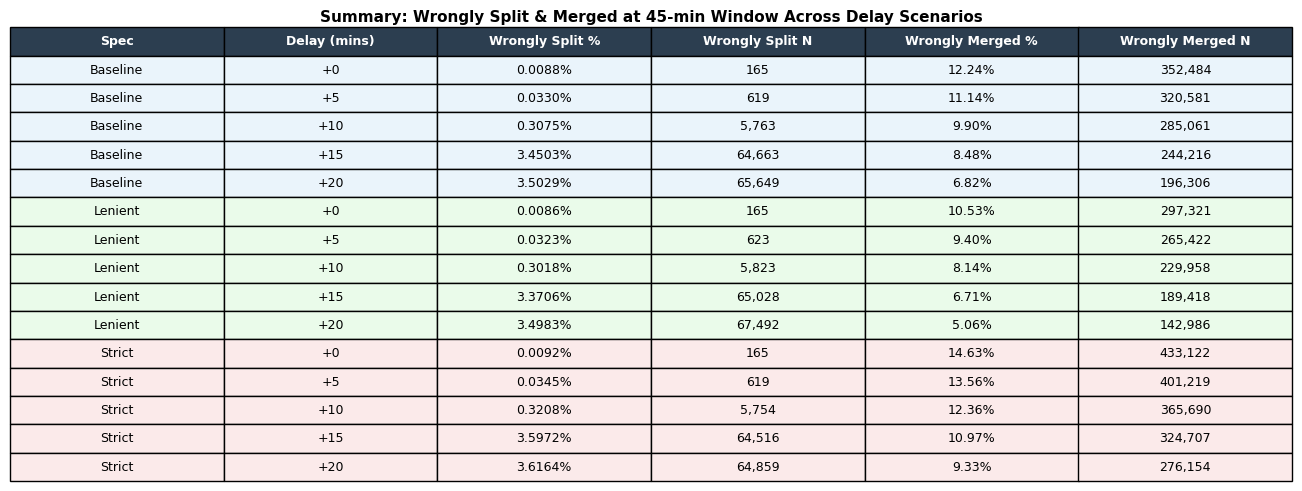

In [35]:
#plot/table 9
summary_rows = []
for spec in specs:
    for delay in delay_scenarios:
        row_data = final_df[
            (final_df['breakdown_type'] == 'overall') &
            (final_df['spec'] == spec) &
            (final_df['delay_mins'] == delay) &
            (final_df['bus_window_mins'] == 45)
        ].iloc[0]
        summary_rows.append({
            'Spec': spec.capitalize(),
            'Delay (mins)': f'+{delay}',
            'Wrongly Split %': f"{row_data['wrongly_split_pct']:.4f}%",
            'Wrongly Split N': f"{int(row_data['wrongly_split_n']):,}",
            'Wrongly Merged %': f"{row_data['wrongly_merged_pct']:.2f}%",
            'Wrongly Merged N': f"{int(row_data['wrongly_merged_n']):,}",
        })

summary_table = pd.DataFrame(summary_rows)

fig, ax = plt.subplots(figsize=(13, 5))
ax.axis('off')
tbl = ax.table(
    cellText=summary_table.values,
    colLabels=summary_table.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.6)

# colour header
for j in range(len(summary_table.columns)):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# colour spec rows alternately
spec_colors_table = {'Baseline': '#eaf4fb', 'Lenient': '#eafbea', 'Strict': '#fbeaea'}
for i, row in enumerate(summary_table.itertuples(), start=1):
    for j in range(len(summary_table.columns)):
        tbl[i, j].set_facecolor(spec_colors_table.get(row.Spec, 'white'))

ax.set_title('Summary: Wrongly Split & Merged at 45-min Window Across Delay Scenarios',
             fontsize=11, fontweight='bold', pad=20)
plt.tight_layout()
#plt.savefig('plot9_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()